# E35 — O instrumento mexe no mundo

O corte dispara a ação declarada e é recalibrado sobre a série que ele mesmo produziu.
**Regras declaradas antes da prosa** (ver docstring do construtor): o laço com fração e atraso de
topo; o controle de fração nula que devolve o mundo intacto; os três critérios de separação. Nada
de número novo sem a dispersão entre mundos junto.

In [1]:
import sys
sys.path.insert(0, "lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from frevolab import laco, mudanca, partilha, promessa, graficos

SEMENTE = 101            # <- brinque com:
MUNDOS_LACO = 24         # mundos sorteados, tudo reportado com dispersão entre eles
N_SERIE = 6718           # o tamanho da série do livro (numSerieDias)
JANELA = 252             # a janela do corte da raiz
POSTO_K = promessa.posto(JANELA)   # o posto que a cauda de 5% escolhe: 13
CICLOS = 5               # voltas do laço por configuração
FRACOES = (0.0, 0.25, 0.5, 1.0)     # a fração vendida a cada rompimento
ATRASOS = (0, 1, 5)                  # <- brinque com: os dias entre o rompimento e a venda
PROMESSA_ASSINADA = promessa.entrega_do_corte(JANELA)   # 13/253, o que o corte assina

print("frevolab", __import__("frevolab").VERSAO, "| posto", POSTO_K,
      "| assinado %.4f" % PROMESSA_ASSINADA, "| mundos", MUNDOS_LACO)

frevolab 0.1.0 | posto 13 | assinado 0.0514 | mundos 24


In [2]:
# Os mundos: nível estável do tamanho da série, um sorteio por mundo. O controle mora na
# fração nula: o laço tem de devolver cada mundo intacto, bit a bit.
SORTEIO = np.random.default_rng(SEMENTE)
MUNDOS = [mudanca.estavel(N_SERIE, SORTEIO) for _ in range(MUNDOS_LACO)]

prova = laco.reage(MUNDOS[0], promessa.corte_no_posto(pd.Series(MUNDOS[0]), JANELA, POSTO_K).to_numpy(),
                   fracao=0.0, atraso=1)
assert np.array_equal(prova, MUNDOS[0]), "a reação nula não devolve o mundo intacto"
print("controle ng1999: reação nula devolve o mundo intacto — ok")

controle ng1999: reação nula devolve o mundo intacto — ok


In [3]:
# O laço inteiro: grade de frações e atrasos, cinco ciclos, mundo a mundo.
HISTORICOS = {}
for fracao in FRACOES:
    for atraso in ATRASOS:
        lista = []
        for mundo in MUNDOS:
            lista.append(laco.recalibra(mundo, JANELA, POSTO_K, ciclos=CICLOS,
                                        fracao=fracao, atraso=atraso))
        HISTORICOS[(fracao, atraso)] = lista
        print("fracao %.2f atraso %d | cortes (medianas): %s" % (
            fracao, atraso,
            ["%.4f" % float(np.median([h["cortes"][j] for h in lista])) for j in range(CICLOS)]))

fracao 0.00 atraso 0 | cortes (medianas): ['-0.0164', '-0.0164', '-0.0164', '-0.0164', '-0.0164']


fracao 0.00 atraso 1 | cortes (medianas): ['-0.0164', '-0.0164', '-0.0164', '-0.0164', '-0.0164']


fracao 0.00 atraso 5 | cortes (medianas): ['-0.0164', '-0.0164', '-0.0164', '-0.0164', '-0.0164']


fracao 0.25 atraso 0 | cortes (medianas): ['-0.0164', '-0.0143', '-0.0127', '-0.0116', '-0.0108']


fracao 0.25 atraso 1 | cortes (medianas): ['-0.0164', '-0.0163', '-0.0159', '-0.0159', '-0.0159']


...

fracao 0.50 atraso 1 | cortes (medianas): ['-0.0164', '-0.0159', '-0.0159', '-0.0159', '-0.0159']


fracao 0.50 atraso 5 | cortes (medianas): ['-0.0164', '-0.0162', '-0.0162', '-0.0162', '-0.0162']


fracao 1.00 atraso 0 | cortes (medianas): ['-0.0164', '-0.0126', '-0.0101', '-0.0085', '-0.0065']


fracao 1.00 atraso 1 | cortes (medianas): ['-0.0164', '-0.0159', '-0.0159', '-0.0159', '-0.0159']


fracao 1.00 atraso 5 | cortes (medianas): ['-0.0164', '-0.0162', '-0.0162', '-0.0162', '-0.0162']


In [4]:
# Critério 1: a entrega final com reação contra a da reação nula, pareada por mundo.
# A diferença pareada elimina o mundo do meio da conta: resta o efeito do laço.
entrega_nula = np.array([h["entregas"][-1] for h in HISTORICOS[(0.0, 1)]])
CRITERIO_UM = {}
for fracao in FRACOES[1:]:
    for atraso in ATRASOS:
        dif = np.array([h["entregas"][-1] for h in HISTORICOS[(fracao, atraso)]]) - entrega_nula
        CRITERIO_UM[(fracao, atraso)] = {
            "mediana": float(np.median(dif)),
            "dispersao": float(np.std(dif, ddof=1)),
            "erro_padrao": float(np.std(dif, ddof=1) / np.sqrt(dif.size)),
        }

# Critério 2: o movimento do corte entre o primeiro e o último ciclo, pareado por mundo.
CRITERIO_DOIS = {}
for fracao in FRACOES[1:]:
    for atraso in ATRASOS:
        hs = HISTORICOS[(fracao, atraso)]
        c1 = np.array([h["cortes"][0] for h in hs])
        c5 = np.array([h["cortes"][-1] for h in hs])
        andou = (c5 - c1) / np.abs(c1)
        CRITERIO_DOIS[(fracao, atraso)] = {
            "mediana_pct": float(np.median(andou) * 100.0),
            "dispersao_pct": float(np.std(andou, ddof=1) * 100.0),
        }
        seq = [float(np.median([h["cortes"][j] for h in HISTORICOS[(fracao, atraso)]])) for j in range(CICLOS)]
        CRITERIO_DOIS[(fracao, atraso)]["sequencia"] = seq

print("entrega nula: mediana %.4f | dispersao %.4f" % (
    float(np.median(entrega_nula)), float(np.std(entrega_nula, ddof=1))))
for chave in sorted(CRITERIO_UM):
    um = CRITERIO_UM[chave]
    print("f%.2f a%d | entrega difere %.4f (disp %.4f)" % (chave[0], chave[1], um["mediana"], um["dispersao"]))

entrega nula: mediana 0.0520 | dispersao 0.0012
f0.25 a0 | entrega difere -0.0036 (disp 0.0018)
f0.25 a1 | entrega difere -0.0002 (disp 0.0007)
f0.25 a5 | entrega difere -0.0003 (disp 0.0006)
f0.50 a0 | entrega difere -0.0043 (disp 0.0021)
f0.50 a1 | entrega difere -0.0002 (disp 0.0006)
f0.50 a5 | entrega difere -0.0003 (disp 0.0006)
f1.00 a0 | entrega difere -0.0049 (disp 0.0014)
f1.00 a1 | entrega difere -0.0002 (disp 0.0006)
f1.00 a5 | entrega difere -0.0003 (disp 0.0006)


In [5]:
# O controle no nível do laço: com fração nula, nada se move — os ciclos são idênticos.
CONTROLE = HISTORICOS[(0.0, 1)]
for h in CONTROLE:
    assert len(set(h["cortes"])) == 1, "corte andou com reação nula"
    assert len(set(h["entregas"])) == 1, "entrega andou com reação nula"
    assert np.array_equal(h["series"][-1], h["series"][0]), "a série andou com reação nula"
taxa_nula = float(np.median([h["entregas"][0] for h in CONTROLE]))
print("controle: laço parado, entrega mediana %.4f contra o assinado %.4f" % (
    taxa_nula, PROMESSA_ASSINADA))

controle: laço parado, entrega mediana 0.0520 contra o assinado 0.0514


In [6]:
# Critério 3: o preço na moeda da partilha. A perda absorvida com e sem reagir, no mesmo
# orçamento de atualizações (ciclo de nível e de corte iguais), sobre o preço que cada série produz.
CICLO_NIVEL = 252
CICLO_CORTE = 252
INICIO_PRECO = 504     # depois das janelas da partilha (21 e 252)

PRECO = {}
for fracao in (0.5, 1.0):
    par = [(partilha.absorvido(1000.0 * np.exp(np.cumsum(h["series"][-1])), CICLO_NIVEL,
                              CICLO_CORTE, inicio=INICIO_PRECO),
            partilha.absorvido(1000.0 * np.exp(np.cumsum(n["series"][-1])), CICLO_NIVEL,
                               CICLO_CORTE, inicio=INICIO_PRECO))
           for h, n in zip(HISTORICOS[(fracao, 1)], CONTROLE)]
    dif = np.array([r - n for r, n in par])
    PRECO[fracao] = {"absorvido_reacao": float(np.median([r for r, _ in par])),
                     "absorvido_nula": float(np.median([n for _, n in par])),
                     "diferenca_mediana": float(np.median(dif)),
                     "diferenca_dispersao": float(np.std(dif, ddof=1))}
    print("fracao %.1f | absorvido %.4f contra %.4f | diferenca %.4f (disp %.4f)" % (
        fracao, PRECO[fracao]["absorvido_reacao"], PRECO[fracao]["absorvido_nula"],
        PRECO[fracao]["diferenca_mediana"], PRECO[fracao]["diferenca_dispersao"]))

fracao 0.5 | absorvido 21.7929 contra 22.1473 | diferenca 0.0679 (disp 6.9070)
fracao 1.0 | absorvido 21.7780 contra 22.1473 | diferenca 0.4003 (disp 7.2157)


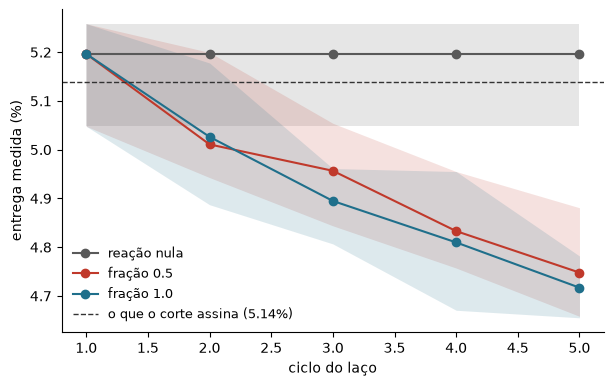

In [7]:
# Figura 1: a entrega ciclo a ciclo no atraso zero (a venda no próprio dia do rompimento),
# com a faixa entre mundos para a fração nula e as duas maiores — e a linha do que o corte assina.
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ciclos_eixo = np.arange(1, CICLOS + 1)
cores = {0.0: "0.35", 0.5: "#c0392b", 1.0: "#1f6f8b"}
for fracao in (0.0, 0.5, 1.0):
    matriz = np.array([HISTORICOS[(fracao, 0)][m]["entregas"] for m in range(MUNDOS_LACO)]) * 100.0
    mediana = np.median(matriz, axis=0)
    ax.plot(ciclos_eixo, mediana, marker="o", color=cores[fracao],
            label=("reação nula" if fracao == 0 else "fração %.1f" % fracao))
    ax.fill_between(ciclos_eixo, np.percentile(matriz, 20, axis=0), np.percentile(matriz, 80, axis=0),
                    color=cores[fracao], alpha=0.15, linewidth=0)
ax.axhline(PROMESSA_ASSINADA * 100.0, color="0.2", linestyle="--", linewidth=1.0,
           label="o que o corte assina (%.2f%%)" % (PROMESSA_ASSINADA * 100.0))
ax.set_xlabel("ciclo do laço")
ax.set_ylabel("entrega medida (%)")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E35_performativos", 1)
plt.show()

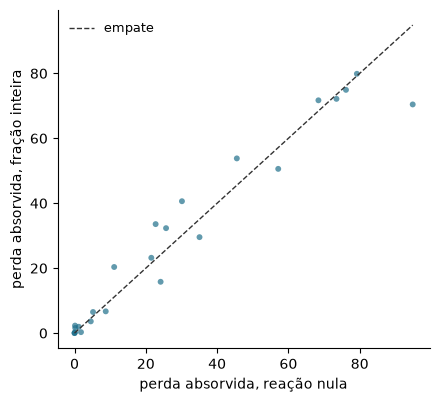

In [8]:
# Figura 2: o preço, pareado por mundo — a perda absorvida com a reação inteira contra a da
# reação nula, um ponto por mundo, a diagonal de empate.
fig, ax = plt.subplots(figsize=(4.8, 4.4))
nulos = np.array([partilha.absorvido(1000.0 * np.exp(np.cumsum(h["series"][-1])), CICLO_NIVEL,
                             CICLO_CORTE, inicio=INICIO_PRECO) for h in CONTROLE])
reacao = np.array([partilha.absorvido(1000.0 * np.exp(np.cumsum(h["series"][-1])), CICLO_NIVEL,
                              CICLO_CORTE, inicio=INICIO_PRECO) for h in HISTORICOS[(1.0, 1)]])
ax.scatter(nulos, reacao, s=18, color="#1f6f8b", alpha=0.7, edgecolor="none")
limite = [min(nulos.min(), reacao.min()), max(nulos.max(), reacao.max())]
ax.plot(limite, limite, color="0.2", linestyle="--", linewidth=1.0, label="empate")
ax.set_xlabel("perda absorvida, reação nula")
ax.set_ylabel("perda absorvida, fração inteira")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E35_performativos", 2)
plt.show()

In [9]:
# Leitura visual das figuras (declaratória, contra o PNG):
# 1) a reação nula é a linha plana no alto (~5,2%), rente à linha do que o corte assina (5,14%);
#    as duas frações caem juntas ciclo a ciclo até ~4,7-4,8% na quinta volta, ainda descendo;
#    a fração 1,0 fica colada na 0,5 --- a saturação da ordem em desenho; as faixas entre mundos
#    se cruzam, e é por isso que a diferença pareada (fora da figura) é quem separa.
# 2) os pontos do preço caem sobre a diagonal de empate, espalhados de 0 a 80 na escala da
#    carteira: a dispersão entre mundos é quem manda, o efeito não aparece em desenho.

In [10]:
# O que sai do laboratório e o que o livro cita.
resultado = {
    "laco_mundos": int(MUNDOS_LACO),
    "laco_ciclos": int(CICLOS),
    "laco_posto": int(POSTO_K),
    "laco_janela": int(JANELA),
    "laco_entrega_nula_mediana": float(np.median(entrega_nula)),
    "laco_entrega_nula_dispersao": float(np.std(entrega_nula, ddof=1)),
    "laco_entrega_meia_fracao_mediana": float(np.median([h["entregas"][-1] for h in HISTORICOS[(0.5, 1)]])),
    "laco_entrega_fracao_inteira_mediana": float(np.median([h["entregas"][-1] for h in HISTORICOS[(1.0, 1)]])),
    "laco_diferenca_meia_fracao_mediana": CRITERIO_UM[(0.5, 1)]["mediana"],
    "laco_diferenca_meia_fracao_dispersao": CRITERIO_UM[(0.5, 1)]["dispersao"],
    "laco_diferenca_fracao_inteira_mediana": CRITERIO_UM[(1.0, 1)]["mediana"],
    "laco_diferenca_fracao_inteira_dispersao": CRITERIO_UM[(1.0, 1)]["dispersao"],
    "laco_diferenca_inteira_atraso_zero_mediana": CRITERIO_UM[(1.0, 0)]["mediana"],
    "laco_diferenca_inteira_atraso_zero_dispersao": CRITERIO_UM[(1.0, 0)]["dispersao"],
    "laco_diferenca_meia_fracao_atraso_zero_mediana": CRITERIO_UM[(0.5, 0)]["mediana"],
    "laco_diferenca_meia_fracao_atraso_zero_dispersao": CRITERIO_UM[(0.5, 0)]["dispersao"],
    "laco_entrega_fracao_inteira_atraso_zero_mediana": float(np.median([h["entregas"][-1] for h in HISTORICOS[(1.0, 0)]])),
    "laco_corte_andou_fracao_inteira_atraso_zero_pct": CRITERIO_DOIS[(1.0, 0)]["mediana_pct"],
    "laco_corte_andou_fracao_inteira_atraso_zero_dispersao_pct": CRITERIO_DOIS[(1.0, 0)]["dispersao_pct"],
    "laco_corte_ciclo_primeiro_fracao_inteira_atraso_zero": CRITERIO_DOIS[(1.0, 0)]["sequencia"][0],
    "laco_corte_ciclo_segundo_fracao_inteira_atraso_zero": CRITERIO_DOIS[(1.0, 0)]["sequencia"][1],
    "laco_corte_ciclo_terceiro_fracao_inteira_atraso_zero": CRITERIO_DOIS[(1.0, 0)]["sequencia"][2],
    "laco_corte_ciclo_quarto_fracao_inteira_atraso_zero": CRITERIO_DOIS[(1.0, 0)]["sequencia"][3],
    "laco_corte_ciclo_quinto_fracao_inteira_atraso_zero": CRITERIO_DOIS[(1.0, 0)]["sequencia"][4],
    "laco_diferenca_inteira_atraso_cinco_mediana": CRITERIO_UM[(1.0, 5)]["mediana"],
    "laco_corte_andou_meia_fracao_pct": CRITERIO_DOIS[(0.5, 1)]["mediana_pct"],
    "laco_corte_andou_meia_fracao_dispersao_pct": CRITERIO_DOIS[(0.5, 1)]["dispersao_pct"],
    "laco_corte_andou_fracao_inteira_pct": CRITERIO_DOIS[(1.0, 1)]["mediana_pct"],
    "laco_corte_andou_fracao_inteira_dispersao_pct": CRITERIO_DOIS[(1.0, 1)]["dispersao_pct"],
    "laco_promessa_assinada_pct": float(PROMESSA_ASSINADA * 100.0),
    "laco_entrega_nula_mediana_pct": round(float(np.median(entrega_nula)) * 100.0, 2),
    "laco_entrega_fracao_inteira_atraso_zero_mediana_pct": round(float(np.median([h["entregas"][-1] for h in HISTORICOS[(1.0, 0)]])) * 100.0, 2),
    "laco_diferenca_inteira_atraso_zero_mediana_pct": round(CRITERIO_UM[(1.0, 0)]["mediana"] * 100.0, 3),
    "laco_diferenca_inteira_atraso_zero_dispersao_pct": round(CRITERIO_UM[(1.0, 0)]["dispersao"] * 100.0, 3),
    "laco_diferenca_fracao_inteira_mediana_pct": round(CRITERIO_UM[(1.0, 1)]["mediana"] * 100.0, 3),
    "laco_diferenca_fracao_inteira_dispersao_pct": round(CRITERIO_UM[(1.0, 1)]["dispersao"] * 100.0, 3),
    "laco_preco_absorvido_nula": PRECO[0.5]["absorvido_nula"],
    "laco_preco_absorvido_meia_fracao": PRECO[0.5]["absorvido_reacao"],
    "laco_preco_absorvido_fracao_inteira": PRECO[1.0]["absorvido_reacao"],
    "laco_preco_diferenca_inteira_mediana": PRECO[1.0]["diferenca_mediana"],
    "laco_preco_diferenca_inteira_dispersao": PRECO[1.0]["diferenca_dispersao"],
    "laco_serie_dias": int(N_SERIE),
}

CITADAS_NO_LIVRO = (
    "laco_corte_andou_fracao_inteira_atraso_zero_dispersao_pct",
    "laco_corte_andou_fracao_inteira_atraso_zero_pct",
    "laco_corte_andou_fracao_inteira_dispersao_pct",
    "laco_corte_andou_fracao_inteira_pct",
    "laco_corte_andou_meia_fracao_pct",
    "laco_corte_ciclo_primeiro_fracao_inteira_atraso_zero",
    "laco_corte_ciclo_quarto_fracao_inteira_atraso_zero",
    "laco_corte_ciclo_quinto_fracao_inteira_atraso_zero",
    "laco_corte_ciclo_segundo_fracao_inteira_atraso_zero",
    "laco_corte_ciclo_terceiro_fracao_inteira_atraso_zero",
    "laco_diferenca_fracao_inteira_dispersao_pct",
    "laco_diferenca_fracao_inteira_mediana_pct",
    "laco_diferenca_inteira_atraso_zero_dispersao_pct",
    "laco_diferenca_inteira_atraso_zero_mediana_pct",
    "laco_entrega_fracao_inteira_atraso_zero_mediana_pct",
    "laco_entrega_nula_mediana_pct",
    "laco_mundos",
    "laco_preco_absorvido_fracao_inteira",
    "laco_preco_absorvido_nula",
    "laco_preco_diferenca_inteira_dispersao",
    "laco_preco_diferenca_inteira_mediana",
    "laco_promessa_assinada_pct",
)
resultado = {k: v for k, v in resultado.items() if k in CITADAS_NO_LIVRO}
import json
with open("lab/resultados/E35_performativos.json", "w", encoding="utf-8") as f:
    json.dump(resultado, f, ensure_ascii=False, indent=1, sort_keys=True)
print(json.dumps(resultado, ensure_ascii=False, indent=1, sort_keys=True))

{
 "laco_corte_andou_fracao_inteira_atraso_zero_dispersao_pct": 4.854789443725726,
 "laco_corte_andou_fracao_inteira_atraso_zero_pct": 58.68792536641936,
 "laco_corte_andou_fracao_inteira_dispersao_pct": 3.4191672980936922,
 "laco_corte_andou_fracao_inteira_pct": 0.10271170057055508,
 "laco_corte_andou_meia_fracao_pct": 0.10271170057055508,
 "laco_corte_ciclo_primeiro_fracao_inteira_atraso_zero": -0.01639801083819213,
 "laco_corte_ciclo_quarto_fracao_inteira_atraso_zero": -0.008487019355518136,
 "laco_corte_ciclo_quinto_fracao_inteira_atraso_zero": -0.006500214395132307,
 "laco_corte_ciclo_segundo_fracao_inteira_atraso_zero": -0.012638159377085099,
 "laco_corte_ciclo_terceiro_fracao_inteira_atraso_zero": -0.010122382914320967,
 "laco_diferenca_fracao_inteira_dispersao_pct": 0.061,
 "laco_diferenca_fracao_inteira_mediana_pct": -0.015,
 "laco_diferenca_inteira_atraso_zero_dispersao_pct": 0.137,
 "laco_diferenca_inteira_atraso_zero_mediana_pct": -0.487,
 "laco_entrega_fracao_inteira_atras